In [13]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn

In [14]:
import pandas as pd
import numpy as np

# Load the dataset (Assuming you downloaded 'diabetes.csv' from Kaggle)
# If using Google Colab, you can upload the file to your workspace
df = pd.read_csv('/content/diabetes.csv')

# Display the first 5 rows
print("--- First 5 Rows ---")
print(df.head())

# Check data types and missing values
print("\n--- Data Info ---")
print(df.info())

--- First 5 Rows ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    in

In [15]:
# Replace 0 with NaN (Not a Number) for columns where 0 makes no sense
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)

# Impute (fill) the missing values with the median of each column
for col in zero_columns:
    df[col] = df[col].fillna(df[col].median())

# Split data into Features (X) and Target/Label (y)
X = df.drop(columns=['Outcome']) # Everything except the Outcome column
y = df['Outcome']                # Only the Outcome column (0 = No Diabetes, 1 = Diabetes)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into Training set (80%) and Testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize the models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Multi-Layer Perceptron": MLPClassifier(max_iter=500, random_state=42)
}

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.get_params() # for ROC-AUC
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

# Convert results to a clean DataFrame for comparison
df_results = pd.DataFrame(results).T.drop(columns=["Confusion Matrix"])
print(df_results)

                        Accuracy Precision    Recall  F1-Score   ROC-AUC
Logistic Regression     0.707792       0.6       0.5  0.545455  0.812963
Random Forest           0.779221  0.717391  0.611111      0.66   0.81787
XGBoost                 0.772727  0.702128  0.611111  0.653465   0.81537
Support Vector Machine   0.74026  0.652174  0.555556       0.6  0.796389
K-Nearest Neighbors     0.753247      0.66  0.611111  0.634615  0.788611
Multi-Layer Perceptron   0.74026  0.659091  0.537037  0.591837  0.810185


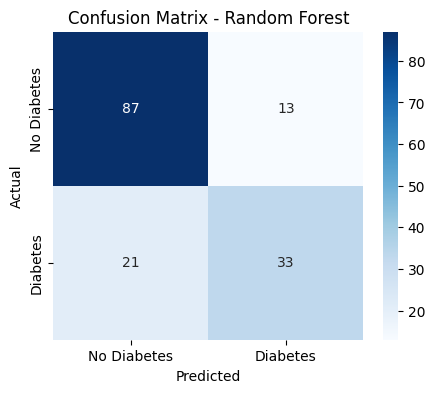

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's plot the confusion matrix for Random Forest
rf_cm = results["Random Forest"]["Confusion Matrix"]

plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [19]:
!pip install gradio scikit-learn pandas numpy xgboost

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('diabetes.csv')

zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully! Ready for Gradio interface.")

Model trained successfully! Ready for Gradio interface.


In [21]:
import gradio as gr

def predict_diabetes(pregnancies, glucose, bp, skin_thickness, insulin, bmi, dpf, age):
    input_data = np.array([[pregnancies, glucose, bp, skin_thickness, insulin, bmi, dpf, age]])

    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    if prediction == 1:
        return f"⚠️ High Risk: The model predicts a DIABETES risk.\nConfidence: {probability*100:.1f}%"
    else:
        return f"✅ Low Risk: The model predicts NO DIABETES.\nConfidence: {(1-probability)*100:.1f}%"

interface = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Number(label="Pregnancies", value=0),
        gr.Slider(minimum=0, maximum=200, value=120, label="Glucose Level (mg/dL)"),
        gr.Slider(minimum=0, maximum=150, value=70, label="Blood Pressure (mm Hg)"),
        gr.Slider(minimum=0, maximum=100, value=20, label="Skin Thickness (mm)"),
        gr.Slider(minimum=0, maximum=900, value=80, label="Insulin Level (mu U/ml)"),
        gr.Slider(minimum=0.0, maximum=60.0, value=25.0, label="BMI (Weight in kg/(height in m)^2)"),
        gr.Slider(minimum=0.0, maximum=2.5, value=0.5, label="Diabetes Pedigree Function"),
        gr.Slider(minimum=1, maximum=120, value=33, label="Age (years)")
    ],
    outputs=gr.Textbox(label="Assessment Result"),
    title="🩸 AI Diabetes Risk Assessment Agent",
    description="Input patient health metrics below to evaluate diabetes risk using Machine Learning.",
    theme="soft"
)

interface.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d78b62c66715968d5b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
